In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score, roc_curve,ConfusionMatrixDisplay,silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans , DBSCAN
from itertools import combinations
from sklearn.decomposition import PCA

In [115]:
df=pd.read_csv('CC GENERAL.csv')

In [116]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [118]:
df.shape

(8950, 18)

In [119]:
num=df.select_dtypes(exclude="object").columns
cat=df.select_dtypes(include="object").columns

In [120]:
df.describe(include=[np.number])

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [121]:
df.drop(columns=['CUST_ID'],inplace=True)

In [122]:
df.isnull().sum().sort_values(ascending=False)

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
CASH_ADVANCE_TRX                      0
CASH_ADVANCE_FREQUENCY                0
PURCHASES_TRX                         0
PAYMENTS                              0
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [123]:
df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

In [124]:
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean(),inplace=True)
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean(),inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_20584\2142197387.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean(),inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_20584\2142197387.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [125]:
df.shape

(8950, 17)

In [126]:
from sklearn.preprocessing import RobustScaler
scale=RobustScaler()
df_scaled = scale.fit_transform(df)
df = pd.DataFrame(df_scaled, columns=df.columns)

In [127]:
# sns.pairplot(df)
# plt.tight_layout()
# plt.show()

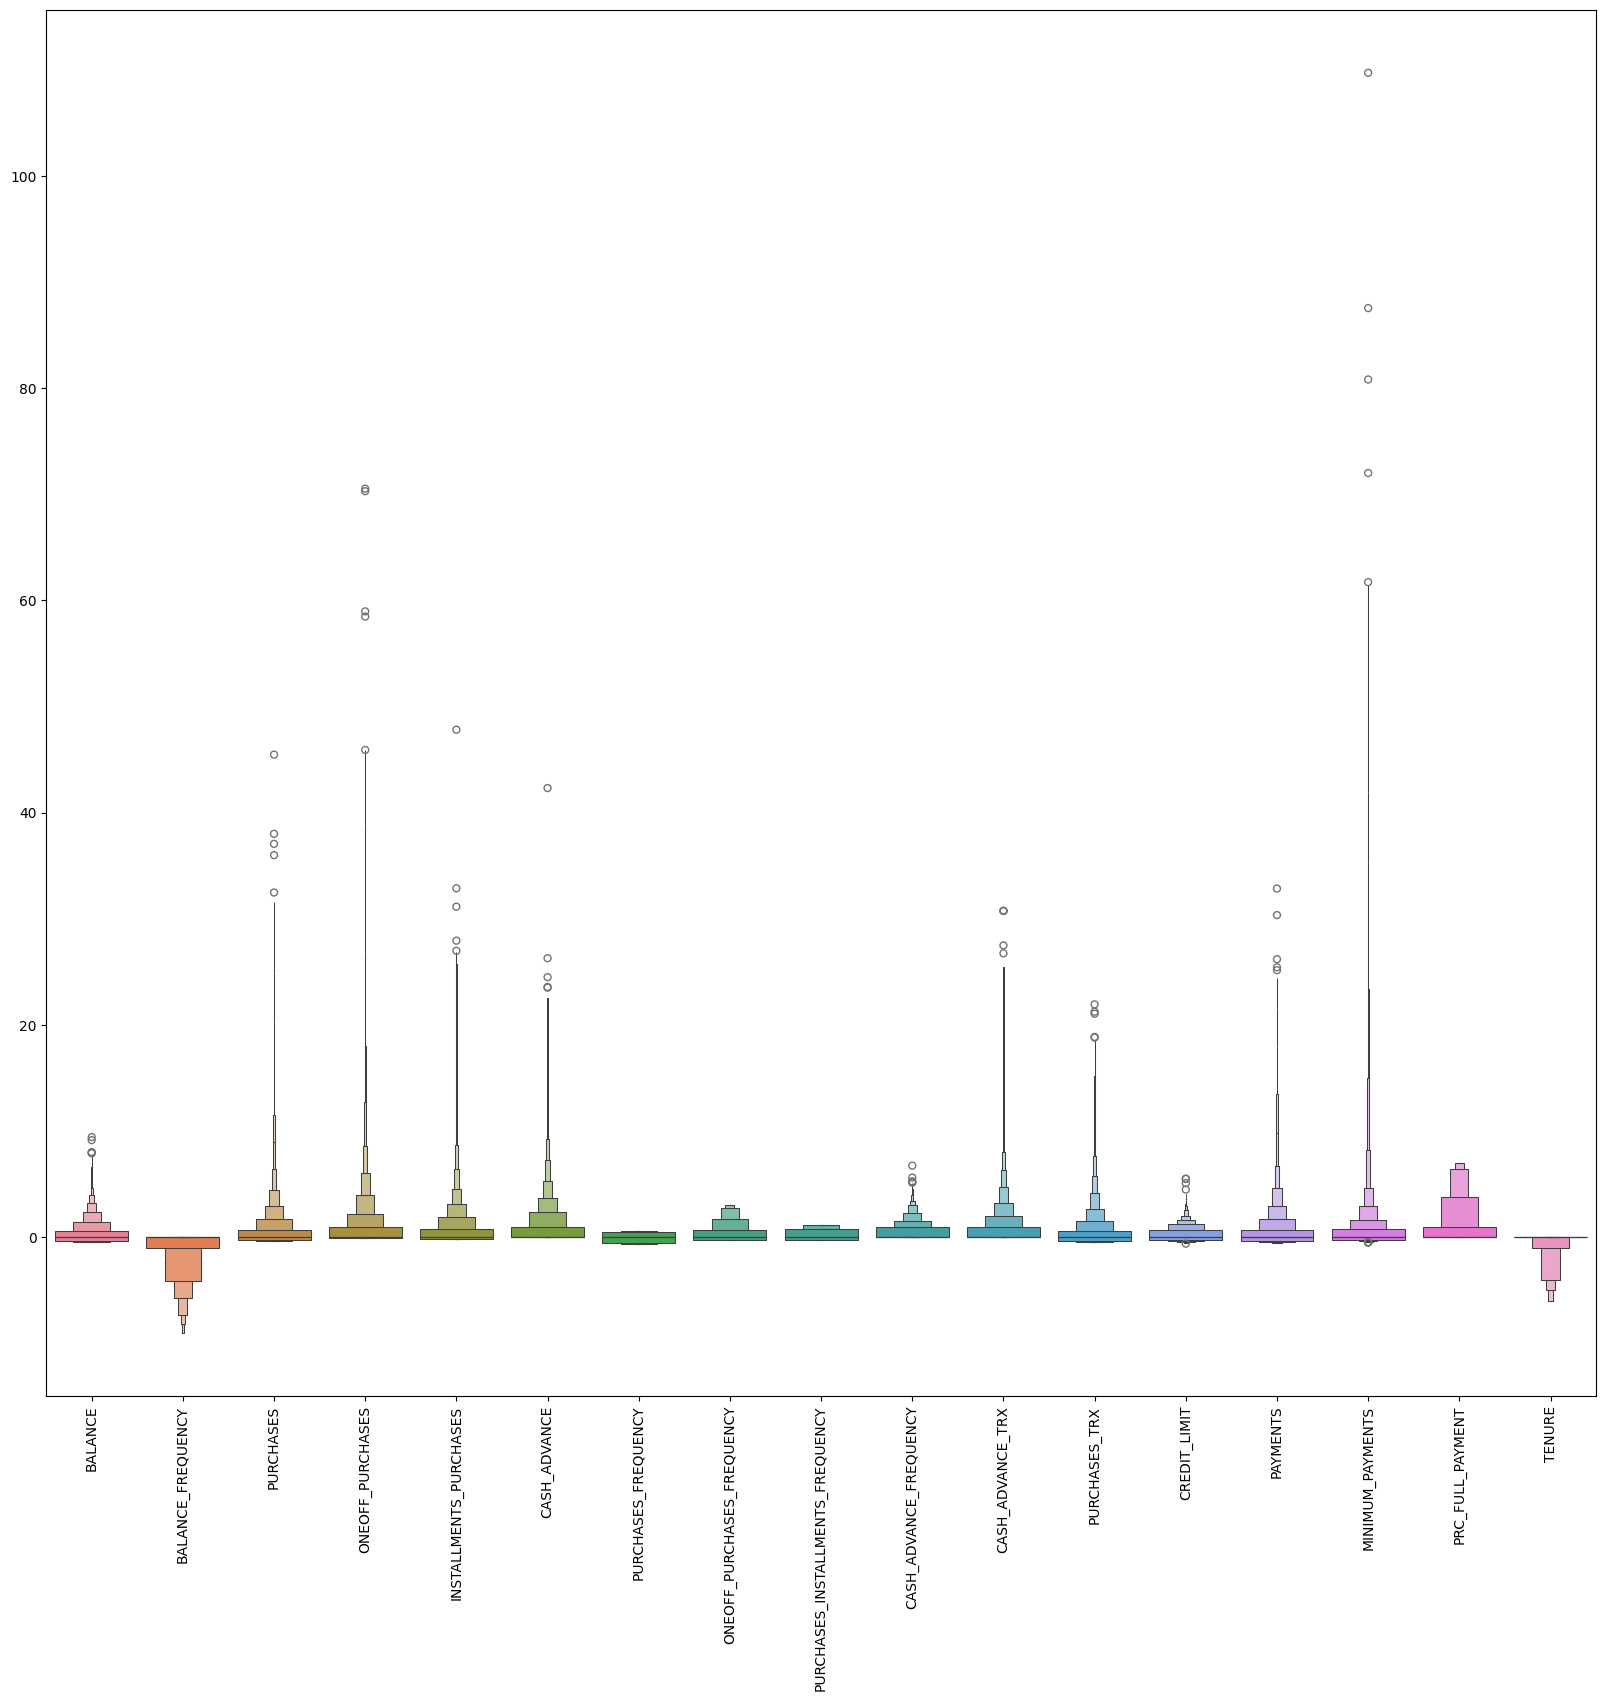

In [128]:
plt.figure(figsize=(20,18))
sns.boxenplot(df)
plt.xticks(rotation=90)
plt.show()

In [129]:
# fit all data with pca because columns >15
pca=PCA(n_components=2)
X=pca.fit_transform(df)

In [130]:
X = pd.DataFrame(X , columns=['S1' , 'S2'])

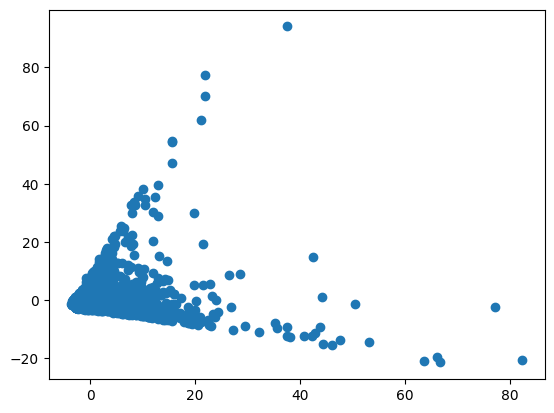

In [131]:
plt.scatter(X['S1'],X['S2'])

In [132]:
score=[]
elbow=[]
for k in range(2,11):
    model = KMeans(n_clusters=k,random_state=42)
    y_pred = model.fit_predict(X)
    score.append(silhouette_score(X,y_pred))
    elbow.append(model.inertia_)
    

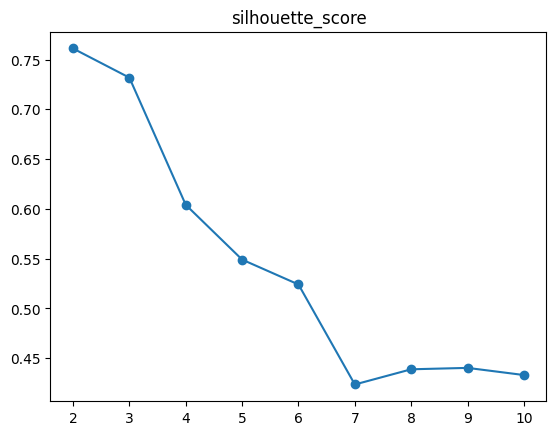

In [133]:
plt.plot(range(2,11),score,marker='o')
plt.title('silhouette_score')
plt.show()

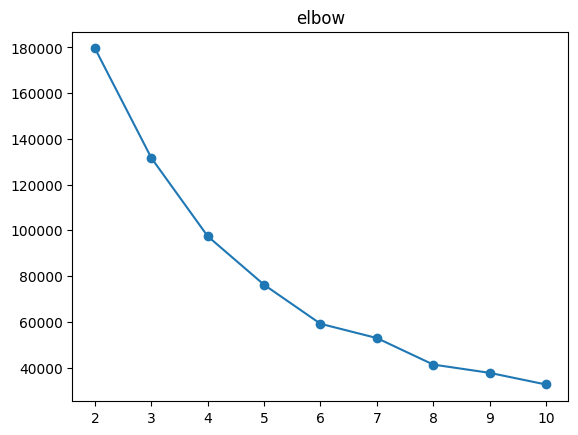

In [134]:
plt.plot(range(2,11),elbow,marker='o')
plt.title('elbow')
plt.show()

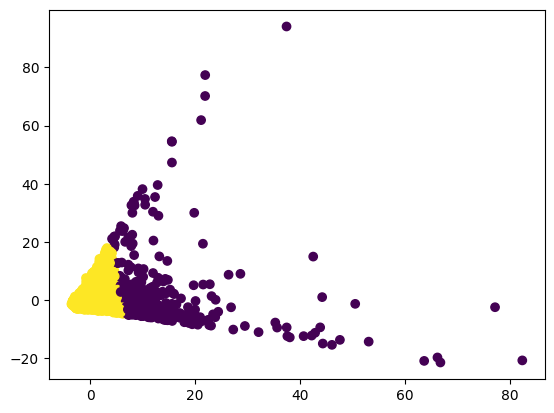

In [135]:
km=KMeans(n_clusters=2,random_state=42)
y_pred=km.fit_predict(X)
plt.scatter(X['S1'],X['S2'],c=km.labels_)
plt.show()

In [136]:
silhouette_score(X,y_pred)

np.float64(0.7610949024779883)

In [137]:
 # try all data 
score=[]
elbow=[]
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42)
    y_pred=model.fit_predict(df)
    elbow.append(model.inertia_)
    score.append(silhouette_score(df,y_pred))

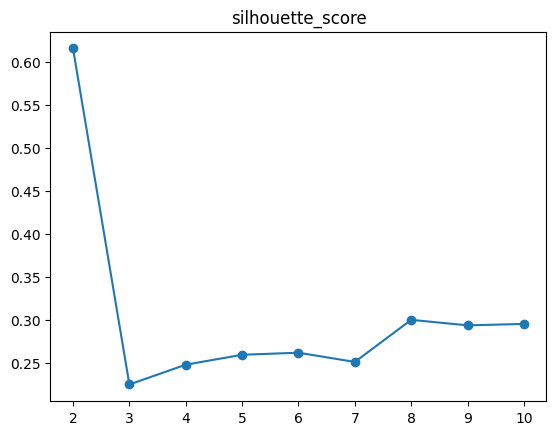

In [138]:
plt.plot(range(2,11),score,marker='o')
plt.title('silhouette_score')
plt.show()

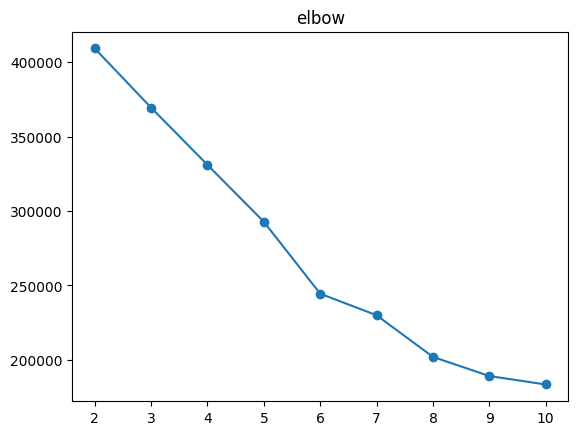

In [139]:
plt.plot(range(2,11),elbow,marker='o')
plt.title('elbow')
plt.show()

In [140]:
pca=PCA(n_components=2)
Z=pca.fit_transform(df)

In [141]:
Z = pd.DataFrame(Z , columns=['S1' , 'S2'])

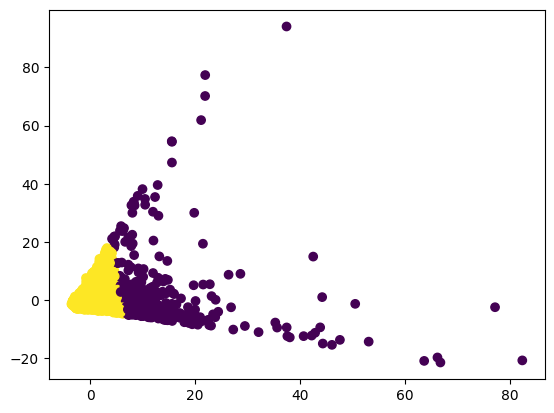

In [142]:
km=KMeans(n_clusters=2,random_state=42)
y_pred=km.fit_predict(Z)
plt.scatter(Z['S1'],Z['S2'],c=km.labels_)
plt.show()

In [143]:
# show best  features we can cluster with it
variances = df.var().sort_values(ascending=False)
print(variances)
top_features = variances.head(10).index
print(top_features)


MINIMUM_PAYMENTS                    11.298671
ONEOFF_PURCHASES                     8.264117
BALANCE_FREQUENCY                    4.546013
PRC_FULL_PAYMENT                     4.192242
PURCHASES                            3.983743
INSTALLMENTS_PURCHASES               3.723811
PAYMENTS                             3.637926
CASH_ADVANCE                         3.545144
CASH_ADVANCE_TRX                     2.910988
PURCHASES_TRX                        2.413682
TENURE                               1.791129
BALANCE                              1.168201
ONEOFF_PURCHASES_FREQUENCY           0.988938
CASH_ADVANCE_FREQUENCY               0.810985
CREDIT_LIMIT                         0.551416
PURCHASES_INSTALLMENTS_FREQUENCY     0.280826
PURCHASES_FREQUENCY                  0.231981
dtype: float64
Index(['MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES', 'BALANCE_FREQUENCY',
       'PRC_FULL_PAYMENT', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'PAYMENTS',
       'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX

In [144]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
best_score=-1
best_k=None
for k in range(2,11):
        mod = KMeans(n_clusters=k,random_state=42)
        y_pred = mod.fit_predict(df[['MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES' ,'BALANCE_FREQUENCY','PRC_FULL_PAYMENT']])
        score=silhouette_score(df[['MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES' ,'BALANCE_FREQUENCY','PRC_FULL_PAYMENT']],y_pred)
        if score > best_score:
            best_score=score
            best_k=k


In [145]:
best_score

np.float64(0.8391520756871245)

In [146]:
best_k

2

In [162]:
mod=KMeans(n_clusters=2,random_state=42)
y_pred=mod.fit_predict(df[['MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES' ,'BALANCE_FREQUENCY','PRC_FULL_PAYMENT']])


In [163]:
new_pca=PCA(n_components=2)
new_x=new_pca.fit_transform(df[['MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES' ,'BALANCE_FREQUENCY','PRC_FULL_PAYMENT']])
new_x=pd.DataFrame(new_x,columns=['X1','X2'])

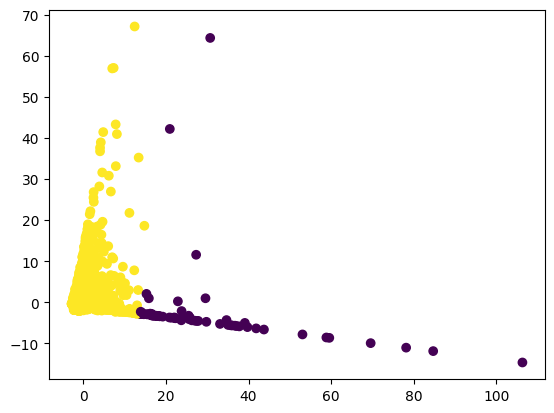

In [164]:
plt.scatter(new_x['X1'],new_x['X2'],c=y_pred)
plt.show()

In [165]:
best_score=-1
best_k=None
for k in range(2,11):
        mod = KMeans(n_clusters=k,random_state=42)
        y_pred = mod.fit_predict(new_x)
        score=silhouette_score(new_x,y_pred)
        if score > best_score:
            best_score=score
            best_k=k

In [166]:
best_score

np.float64(0.8982492745137199)

In [167]:
best_k

2

In [168]:
mode=KMeans(n_clusters=2,random_state=42)
mode.fit(new_x)

KMeans(n_clusters=2, random_state=42)

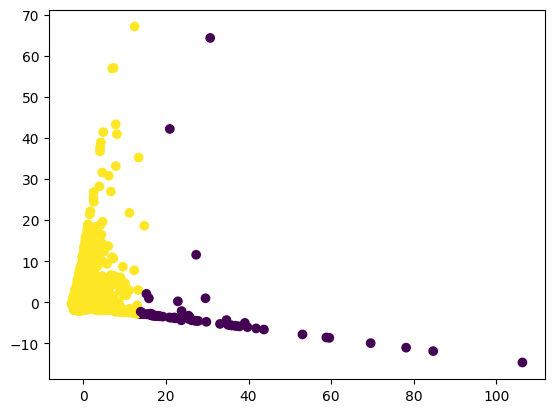

In [169]:
plt.scatter(new_x['X1'],new_x['X2'],c=mode.labels_)
plt.show()

In [170]:
dbscan=DBSCAN(eps=0.8,min_samples=3)
y_pred=dbscan.fit_predict(new_x)
silhouette_score(new_x,y_pred)

np.float64(0.6094857563919176)

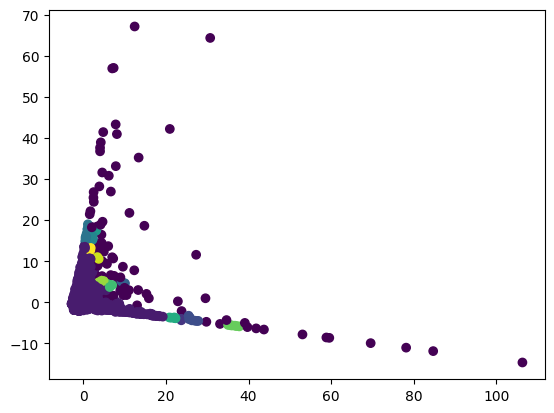

In [171]:
plt.scatter(new_x['X1'],new_x['X2'],c=dbscan.labels_)
plt.show()